## 1. Setup
Mount Google Drive and clone the project repository containing EoMT model code, configs, and training scripts.

In [ ]:
# Mount drive and clone repo
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/AlessandroMarinai/MaskArchitectureAnomaly_CourseProject
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt
!pip install -q timm lightning transformers torchmetrics fvcore

Mounted at /content/drive
Cloning into 'MaskArchitectureAnomaly_CourseProject'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 131 (delta 22), reused 19 (delta 19), pack-reused 75 (from 1)
Receiving objects: 100% (131/131), 26.88 MiB | 42.40 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/MaskArchitectureAnomaly_CourseProject/eomt
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 47.5 MB/

## 2. Imports
Core libraries: PyTorch, Lightning, NumPy, Matplotlib. Helper functions `create_mapping` and `apply_colormap` are used to colorize segmentation predictions for visualization.

In [ ]:
import sys
sys.path.insert(0, '/content/MaskArchitectureAnomaly_CourseProject/eomt')

import yaml
import warnings
import importlib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from lightning import seed_everything
from torch.amp.autocast_mode import autocast

seed_everything(0, verbose=False)

# TODO: change to 0 if no GPU
device = 0 if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Helper functions from inference.ipynb
def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping

def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

Using device: 0


## 3. Load Cityscapes Model
Load the EoMT model trained on Cityscapes for **semantic segmentation** (19 classes) using the repo's config file `eomt_base_640.yaml`. The Cityscapes validation set (500 images) is loaded for evaluation.

In [ ]:
# ---- CITYSCAPES SEMANTIC MODEL ----
config_path = "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
data_path = "/content/drive/MyDrive/MLDL_NewVersionProject/cityscapes"

# Load config
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Load dataset
data_module_name, class_name = config["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config["data"].get("init_args", {})
data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
).setup()

# Load encoder
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

# Load network
network_cfg = config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=data.num_classes,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
warnings.filterwarnings("ignore", message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*")
lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

model_city = lit_cls(
    img_size=data.img_size,
    num_classes=data.num_classes,
    network=network,
    **model_kwargs,
).eval().to(device)

# Load weights from Drive (not HuggingFace)
CKPT_CITY = '/content/drive/MyDrive/MLDL_NewVersionProject/eomt_cityscapes.bin'
state_dict = torch.load(CKPT_CITY, map_location=f"cuda:{device}" if torch.cuda.is_available() else "cpu", weights_only=True)
missing, unexpected = model_city.load_state_dict(state_dict, strict=False)
print(f"✅ Cityscapes model loaded | Missing: {len(missing)} | Unexpected: {len(unexpected)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✅ Cityscapes model loaded | Missing: 0 | Unexpected: 0


## 4. Load COCO Model
Load the EoMT model trained on COCO for **panoptic segmentation** (133 classes) using `eomt_base_640_2x.yaml`. The checkpoint uses patch_size=16 and img_size=640×640 (detected automatically from checkpoint).

In [ ]:
# ---- COCO PANOPTIC MODEL ----
config_path_coco = "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"

with open(config_path_coco, "r") as f:
    config_coco = yaml.safe_load(f)

COCO_IMG_SIZE = (560, 560)  # detected from checkpoint

# Load encoder — force img_size, ignore config's img_size
encoder_cfg2 = config_coco["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name2, encoder_class_name2 = encoder_cfg2["class_path"].rsplit(".", 1)
encoder_cls2 = getattr(importlib.import_module(encoder_module_name2), encoder_class_name2)
encoder_init2 = {k: v for k, v in encoder_cfg2.get("init_args", {}).items()}
encoder_init2["img_size"] = (640, 640)  # correct size
encoder_init2["patch_size"] = 16        # checkpoint uses patch_size=16
encoder2 = encoder_cls2(**encoder_init2)

# Load network
network_cfg2 = config_coco["model"]["init_args"]["network"]
network_module_name2, network_class_name2 = network_cfg2["class_path"].rsplit(".", 1)
network_cls2 = getattr(importlib.import_module(network_module_name2), network_class_name2)
network_kwargs2 = {k: v for k, v in network_cfg2["init_args"].items() if k != "encoder"}
network2 = network_cls2(
    masked_attn_enabled=False,
    num_classes=133,
    encoder=encoder2,
    **network_kwargs2,
)

# Load Lightning module
warnings.filterwarnings("ignore", message=r".*Attribute 'network'.*")
lit_module_name2, lit_class_name2 = config_coco["model"]["class_path"].rsplit(".", 1)
lit_cls2 = getattr(importlib.import_module(lit_module_name2), lit_class_name2)
model_kwargs2 = {k: v for k, v in config_coco["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in config_coco["data"].get("init_args", {}):
    model_kwargs2["stuff_classes"] = config_coco["data"]["init_args"]["stuff_classes"]

model_coco = lit_cls2(
    img_size=(640, 640),  # change this too
    num_classes=133,
    network=network2,
    **model_kwargs2,
).eval().to(device)

# Load weights
CKPT_COCO = '/content/drive/MyDrive/MLDL_NewVersionProject/eomt_coco.bin'
state_dict2 = torch.load(CKPT_COCO, map_location=f"cuda:{device}" if torch.cuda.is_available() else "cpu", weights_only=True)
missing2, unexpected2 = model_coco.load_state_dict(state_dict2, strict=False)
print(f"✅ COCO model loaded | Missing: {len(missing2)} | Unexpected: {len(unexpected2)}")

✅ COCO model loaded | Missing: 0 | Unexpected: 0


## 5. Semantic Inference Function
`infer_semantic()` runs the Cityscapes model on a single image using the sliding window approach from `inference.ipynb`. Returns per-pixel class predictions (0-18) and ground truth labels.

In [ ]:
IGNORE_INDEX = 255

def infer_semantic(img, target):
    """Semantic inference using Cityscapes model"""
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model_city.window_imgs_semantic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_city(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data.img_size, mode="bilinear"
        )
        crop_logits = model_city.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model_city.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model_city.to_per_pixel_targets_semantic(
        [target], IGNORE_INDEX
    )[0].numpy()
    return pred_array, target_array


def infer_panoptic(img):
    """Panoptic inference using COCO model"""
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        transformed_imgs = model_coco.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_coco(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model_coco.img_size, mode="bilinear"
        )
        mask_logits = model_coco.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )
        preds = model_coco.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model_coco.stuff_classes,
            model_coco.mask_thresh,
            model_coco.overlap_thresh,
        )[0].cpu().numpy()

    sem_pred = preds[..., 0]   # semantic class map (COCO IDs)
    inst_pred = preds[..., 1]  # instance map
    return sem_pred, inst_pred

## 6. Visualization — Semantic vs Panoptic
Side-by-side comparison of the two models on the same Cityscapes validation image:
- **Left**: Input image
- **Center**: EoMT-Cityscapes semantic prediction (19 classes, each pixel assigned a road-scene class)
- **Right**: EoMT-COCO panoptic prediction (133 classes, each instance gets a unique color)

Note: The visualization uses ALL classes from each model — not the common class subset used for quantitative evaluation.

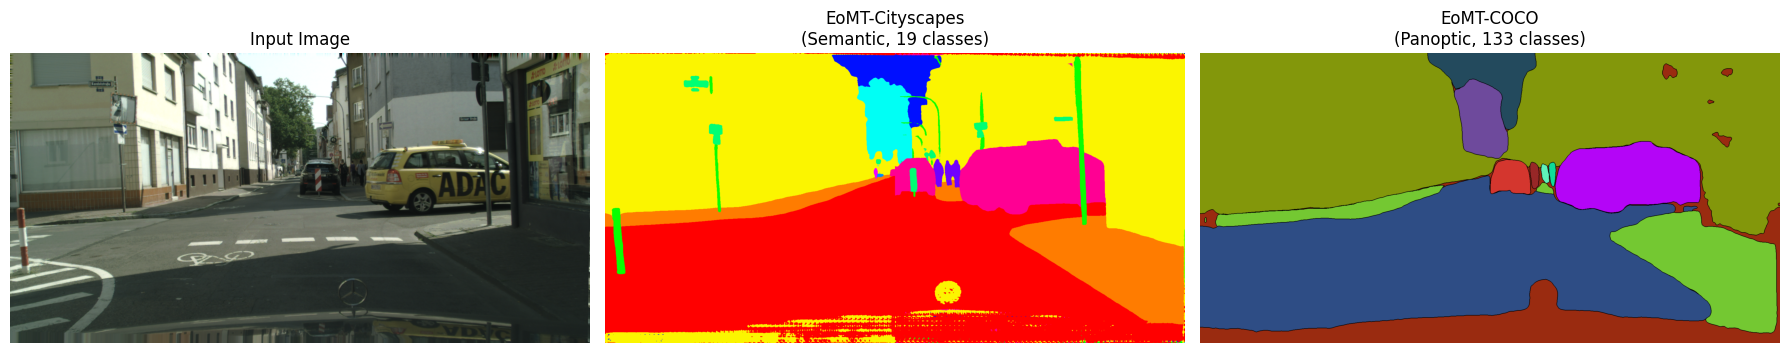

✅ Saved fixed panoptic visualization


In [ ]:
# CORRECT panoptic visualization - each instance gets unique color
def visualize_panoptic(sem_pred, inst_pred, image):
    """
    Each unique (semantic_class, instance_id) pair gets a different color.
    Same class but different instances = different colors.
    """
    h, w = sem_pred.shape
    vis = np.zeros((h, w, 3), dtype=np.float32)

    # Create unique ID for each segment: sem_id * 1000 + inst_id
    unique_segments = np.unique(sem_pred * 1000 + inst_pred)

    # Assign random but consistent color to each unique segment
    np.random.seed(42)
    for seg_id in unique_segments:
        sem_id = seg_id // 1000
        inst_id = seg_id % 1000

        # Skip background/void
        if sem_id < 0 or sem_id == 133:
            continue

        mask = (sem_pred * 1000 + inst_pred) == seg_id
        color = np.random.rand(3)  # unique color per instance
        vis[mask] = color

    # Draw black borders between instances
    combined = (sem_pred * 1000 + inst_pred)
    border = np.zeros((h, w), dtype=bool)
    border[1:,  :] |= combined[1:,  :] != combined[:-1, :]
    border[:-1, :] |= combined[1:,  :] != combined[:-1, :]
    border[:,  1:] |= combined[:,  1:] != combined[:, :-1]
    border[:, :-1] |= combined[:,  1:] != combined[:, :-1]
    vis[border] = 0  # black borders

    return vis

# Re-run visualization with correct panoptic style
img_idx = 0
img, target = data.val_dataloader().dataset[img_idx]

pred_city, target_array = infer_semantic(img, target)
sem_pred_coco, inst_pred_coco = infer_panoptic(img)

# Convert to numpy
sem_np  = sem_pred_coco.cpu().numpy() if torch.is_tensor(sem_pred_coco) else sem_pred_coco
inst_np = inst_pred_coco.cpu().numpy() if torch.is_tensor(inst_pred_coco) else inst_pred_coco

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img.permute(1,2,0).cpu().numpy())
axes[0].set_title("Input Image")
axes[0].axis("off")

mapping = create_mapping([pred_city, target_array], IGNORE_INDEX)
axes[1].imshow(apply_colormap(pred_city, mapping))
axes[1].set_title("EoMT-Cityscapes\n(Semantic, 19 classes)")
axes[1].axis("off")

# Correct panoptic visualization
pan_vis = visualize_panoptic(sem_np, inst_np, img)
axes[2].imshow(pan_vis)
axes[2].set_title("EoMT-COCO\n(Panoptic, 133 classes)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("step4_visualization_fixed.png", dpi=150)
plt.show()
print("✅ Saved fixed panoptic visualization")

# Visualization_2

In [ ]:
# CORRECT panoptic visualization - each instance gets unique color
def visualize_panoptic(sem_pred, inst_pred, image=None):
    """
    Each unique (semantic_class, instance_id) pair gets a different color.
    Same class but different instances = different colors.
    """
    h, w = sem_pred.shape
    vis = np.zeros((h, w, 3), dtype=np.float32)

    # Create unique ID for each segment: sem_id * 1000 + inst_id
    combined = sem_pred * 1000 + inst_pred
    unique_segments = np.unique(combined)

    # Assign random but consistent color to each unique segment
    np.random.seed(42)

    for seg_id in unique_segments:
        sem_id = seg_id // 1000
        inst_id = seg_id % 1000

        # Skip background/void
        if sem_id < 0 or sem_id == 133:
            continue

        mask = combined == seg_id
        color = np.random.rand(3)
        vis[mask] = color

    # Draw black borders between instances
    border = np.zeros((h, w), dtype=bool)

    border[1:,  :] |= combined[1:,  :] != combined[:-1, :]
    border[:-1, :] |= combined[1:,  :] != combined[:-1, :]
    border[:,  1:] |= combined[:,  1:] != combined[:, :-1]
    border[:, :-1] |= combined[:,  1:] != combined[:, :-1]

    vis[border] = 0

    return vis

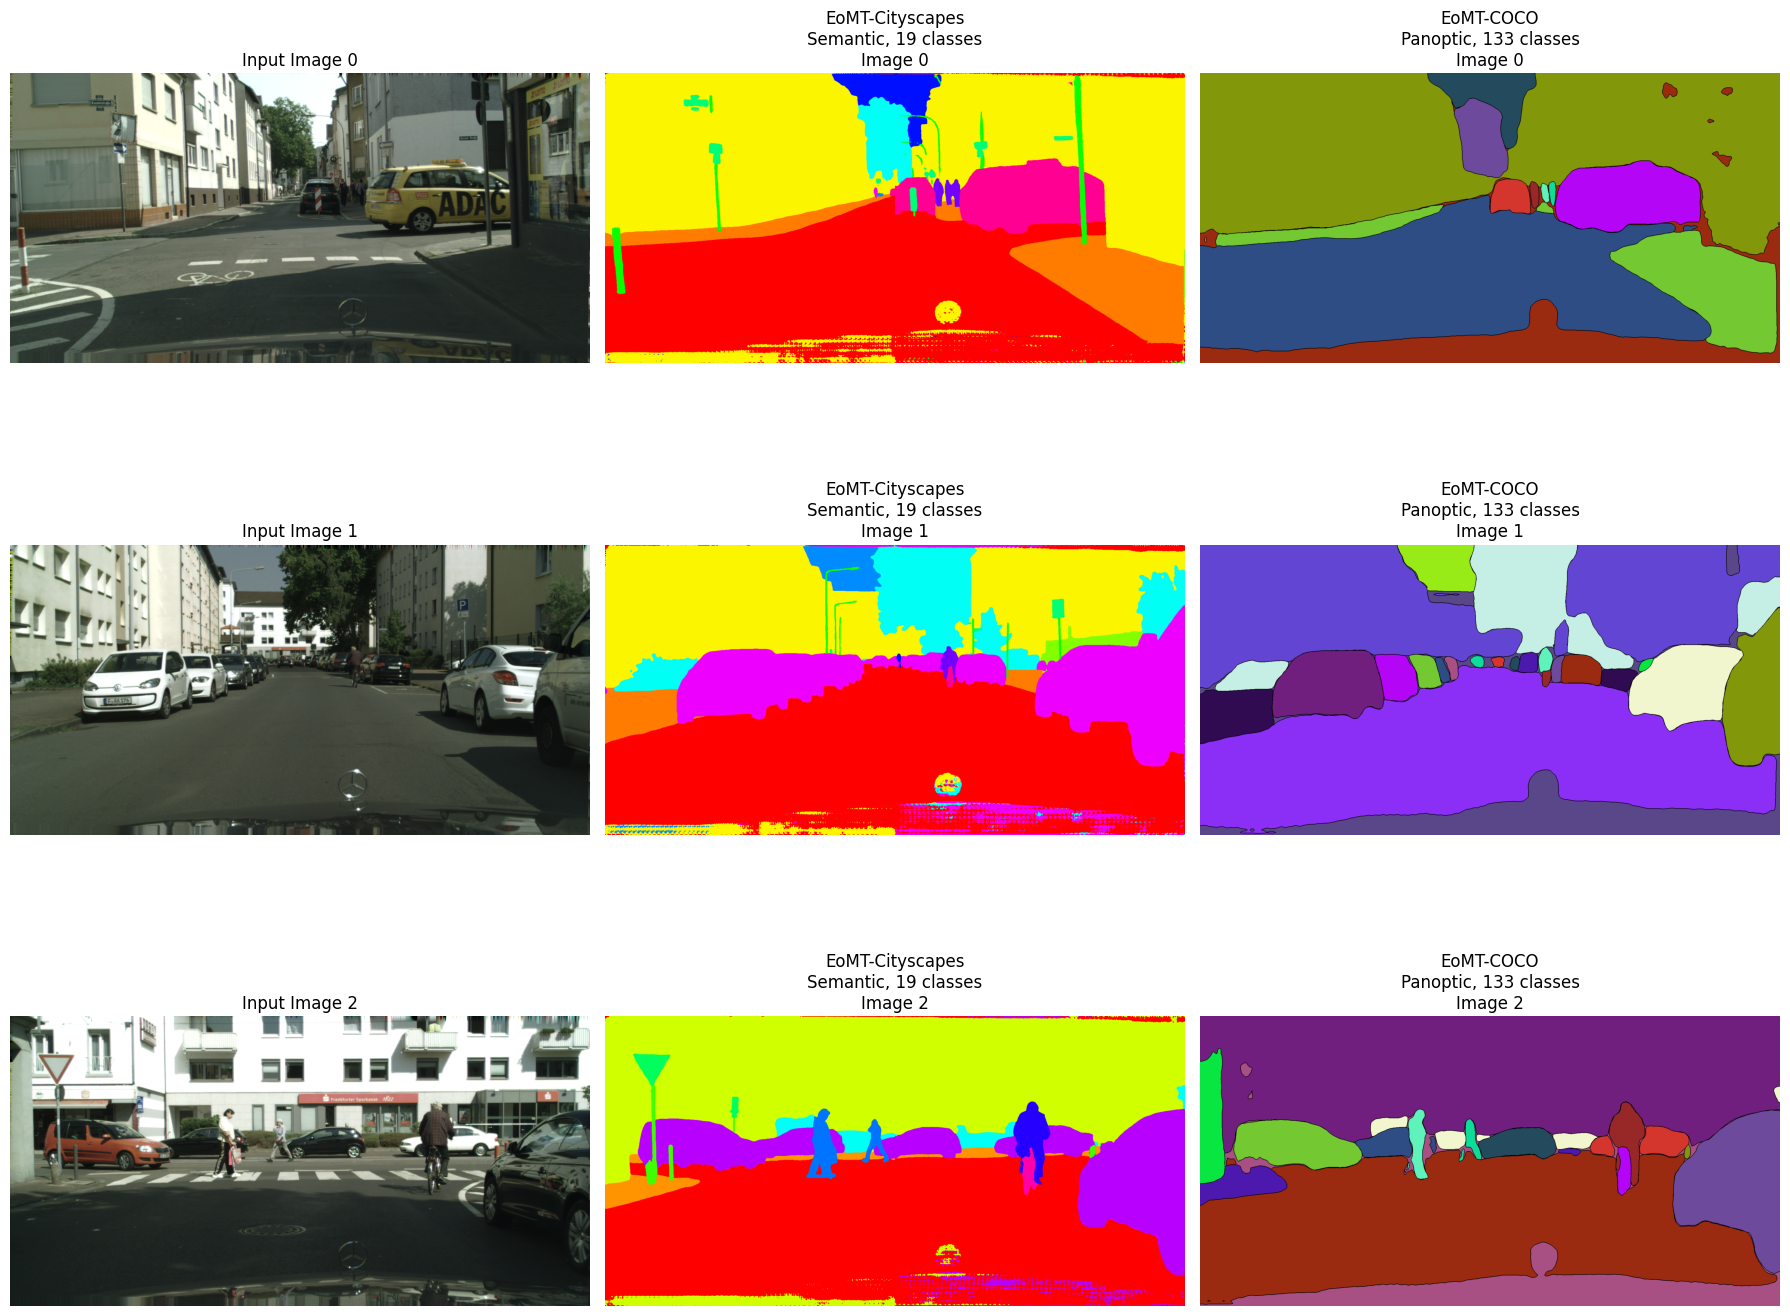

✅ Saved fixed panoptic visualization for 3 images


In [ ]:
# Visualize 3 validation examples
image_indices = [0, 1, 2]   # change these if you want different examples

fig, axes = plt.subplots(
    len(image_indices),
    3,
    figsize=(18, 5 * len(image_indices))
)

for row, img_idx in enumerate(image_indices):
    img, target = data.val_dataloader().dataset[img_idx]

    # Cityscapes semantic prediction
    pred_city, target_array = infer_semantic(img, target)

    # COCO panoptic prediction
    sem_pred_coco, inst_pred_coco = infer_panoptic(img)

    # Convert to numpy
    sem_np = (
        sem_pred_coco.cpu().numpy()
        if torch.is_tensor(sem_pred_coco)
        else sem_pred_coco
    )

    inst_np = (
        inst_pred_coco.cpu().numpy()
        if torch.is_tensor(inst_pred_coco)
        else inst_pred_coco
    )

    # Input image
    img_np = img.permute(1, 2, 0).cpu().numpy()

    # If image was normalized, uncomment and adapt this:
    # img_np = np.clip(img_np, 0, 1)

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"Input Image {img_idx}")
    axes[row, 0].axis("off")

    # Semantic visualization
    mapping = create_mapping([pred_city, target_array], IGNORE_INDEX)
    city_vis = apply_colormap(pred_city, mapping)

    axes[row, 1].imshow(city_vis)
    axes[row, 1].set_title(
        f"EoMT-Cityscapes\nSemantic, 19 classes\nImage {img_idx}"
    )
    axes[row, 1].axis("off")

    # Panoptic visualization
    pan_vis = visualize_panoptic(sem_np, inst_np, img)

    axes[row, 2].imshow(pan_vis)
    axes[row, 2].set_title(
        f"EoMT-COCO\nPanoptic, 133 classes\nImage {img_idx}"
    )
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("step4_visualization_fixed_3_images.png", dpi=150)
plt.show()

print("✅ Saved fixed panoptic visualization for 3 images")

## 7. Quantitative Evaluation — Cityscapes Model
Evaluate EoMT-Cityscapes on the **full Cityscapes validation set** (500 images, all 19 classes) using a confusion matrix to compute mIoU. This is the standard Cityscapes benchmark metric.

In [ ]:
from tqdm import tqdm

def compute_miou(conf, num_classes=19):
    ious = []
    for c in range(num_classes):
        tp = conf[c, c]
        fp = conf[:, c].sum() - tp
        fn = conf[c, :].sum() - tp
        denom = tp + fp + fn
        ious.append(tp / denom if denom > 0 else float('nan'))
    valid = [x for x in ious if not np.isnan(x)]
    return np.mean(valid) * 100, ious

dataset = data.val_dataloader().dataset
conf_city = np.zeros((19, 19), dtype=np.int64)

print("Evaluating EoMT-Cityscapes on full val set (500 images)...")
for i in tqdm(range(len(dataset))):
    img, target = dataset[i]
    pred, gt = infer_semantic(img, target)
    valid = gt != IGNORE_INDEX
    np.add.at(conf_city, (gt[valid], pred[valid]), 1)

miou_city, iou_per_class_city = compute_miou(conf_city)
print(f"\n✅ EoMT-Cityscapes mIoU: {miou_city:.2f}%")  # expect ~81%

Evaluating EoMT-Cityscapes on full val set (500 images)...


100%|██████████| 500/500 [04:27<00:00,  1.87it/s]


✅ EoMT-Cityscapes mIoU: 81.68%


## 8. Fair Cross-Model Evaluation Strategy
**Challenge**: COCO (133 classes) and Cityscapes (19 classes) have completely different class spaces — direct comparison is impossible.

**Solution**: Evaluate both models on **8 common "thing" classes** shared by both datasets: person, car, truck, bus, train, motorcycle, bicycle, traffic light.

Both models use the same semantic per-pixel IoU pipeline. COCO class IDs are mapped to Cityscapes using `COCO_PANOPTIC_CLASS_MAPPING` from the repository. The strict evaluation penalizes COCO for pixels it predicts outside the shared class space.

In [ ]:
# COCO panoptic category ID → Cityscapes train ID
# Based on official COCO panoptic category list
COCO_IDX_TO_CITY = {
    # Things
    1: 11,   # person
    2: 18,   # bicycle
    3: 13,   # car
    4: 17,   # motorcycle
    6: 15,   # bus
    7: 16,   # train
    8: 14,   # truck
    # Stuff
    100: 9,  # dirt-merged → terrain
    116: 8,  # tree-merged → vegetation
    117: 8,  # bush-merged → vegetation
    118: 9,  # grass-merged → terrain
    119: 10, # sky-other-merged → sky
    120: 3,  # wall-brick → wall
    121: 3,  # wall-stone → wall
    122: 3,  # wall-tile → wall
    123: 3,  # wall-wood → wall
    124: 2,  # building-merged → building
    125: 4,  # fence-merged → fence
    126: 5,  # pole → pole
    127: 6,  # traffic light → traffic light
    128: 0,  # road → road
    129: 1,  # pavement-merged → sidewalk
    130: 7,  # stop sign → traffic sign
    131: 9,  # gravel → terrain
    132: 2,  # house → building
    133: 9,  # sand → terrain
}

print(f"Mapped {len(COCO_IDX_TO_CITY)} COCO → Cityscapes classes")
print("Unique pred values found:", np.unique(sem_pred_coco))

# Check which pred values we can map
img, target = data.val_dataloader().dataset[0]
sem_pred_test, _ = infer_panoptic(img)
print("Mappable:", [v for v in np.unique(sem_pred_test) if v in COCO_IDX_TO_CITY])
print("Unmappable:", [v for v in np.unique(sem_pred_test) if v not in COCO_IDX_TO_CITY])

# Evaluate
conf_coco = np.zeros((19, 19), dtype=np.int64)

print("\nEvaluating EoMT-COCO on Cityscapes val set...")
for i in tqdm(range(len(dataset))):
    img, target = dataset[i]
    sem_pred_coco, _ = infer_panoptic(img)

    # remap COCO IDs → Cityscapes train IDs
    remapped = np.full_like(sem_pred_coco, IGNORE_INDEX)
    for coco_idx, city_id in COCO_IDX_TO_CITY.items():
        remapped[sem_pred_coco == coco_idx] = city_id

    _, gt = infer_semantic(img, target)
    valid = (gt != IGNORE_INDEX) & (remapped != IGNORE_INDEX)
    np.add.at(conf_coco, (gt[valid], remapped[valid]), 1)

miou_coco, iou_per_class_coco = compute_miou(conf_coco)
print(f"\n✅ EoMT-COCO mIoU (mapped): {miou_coco:.2f}%")  # expect ~40-50%

Mapped 26 COCO → Cityscapes classes
Unique pred values found: [  0   2 100 116 119 123 129 133]
Mappable: [np.int64(2), np.int64(100), np.int64(116), np.int64(119), np.int64(123), np.int64(129), np.int64(133)]
Unmappable: [np.int64(0)]

Evaluating EoMT-COCO on Cityscapes val set...


100%|██████████| 500/500 [07:44<00:00,  1.08it/s]


✅ EoMT-COCO mIoU (mapped): 9.15%


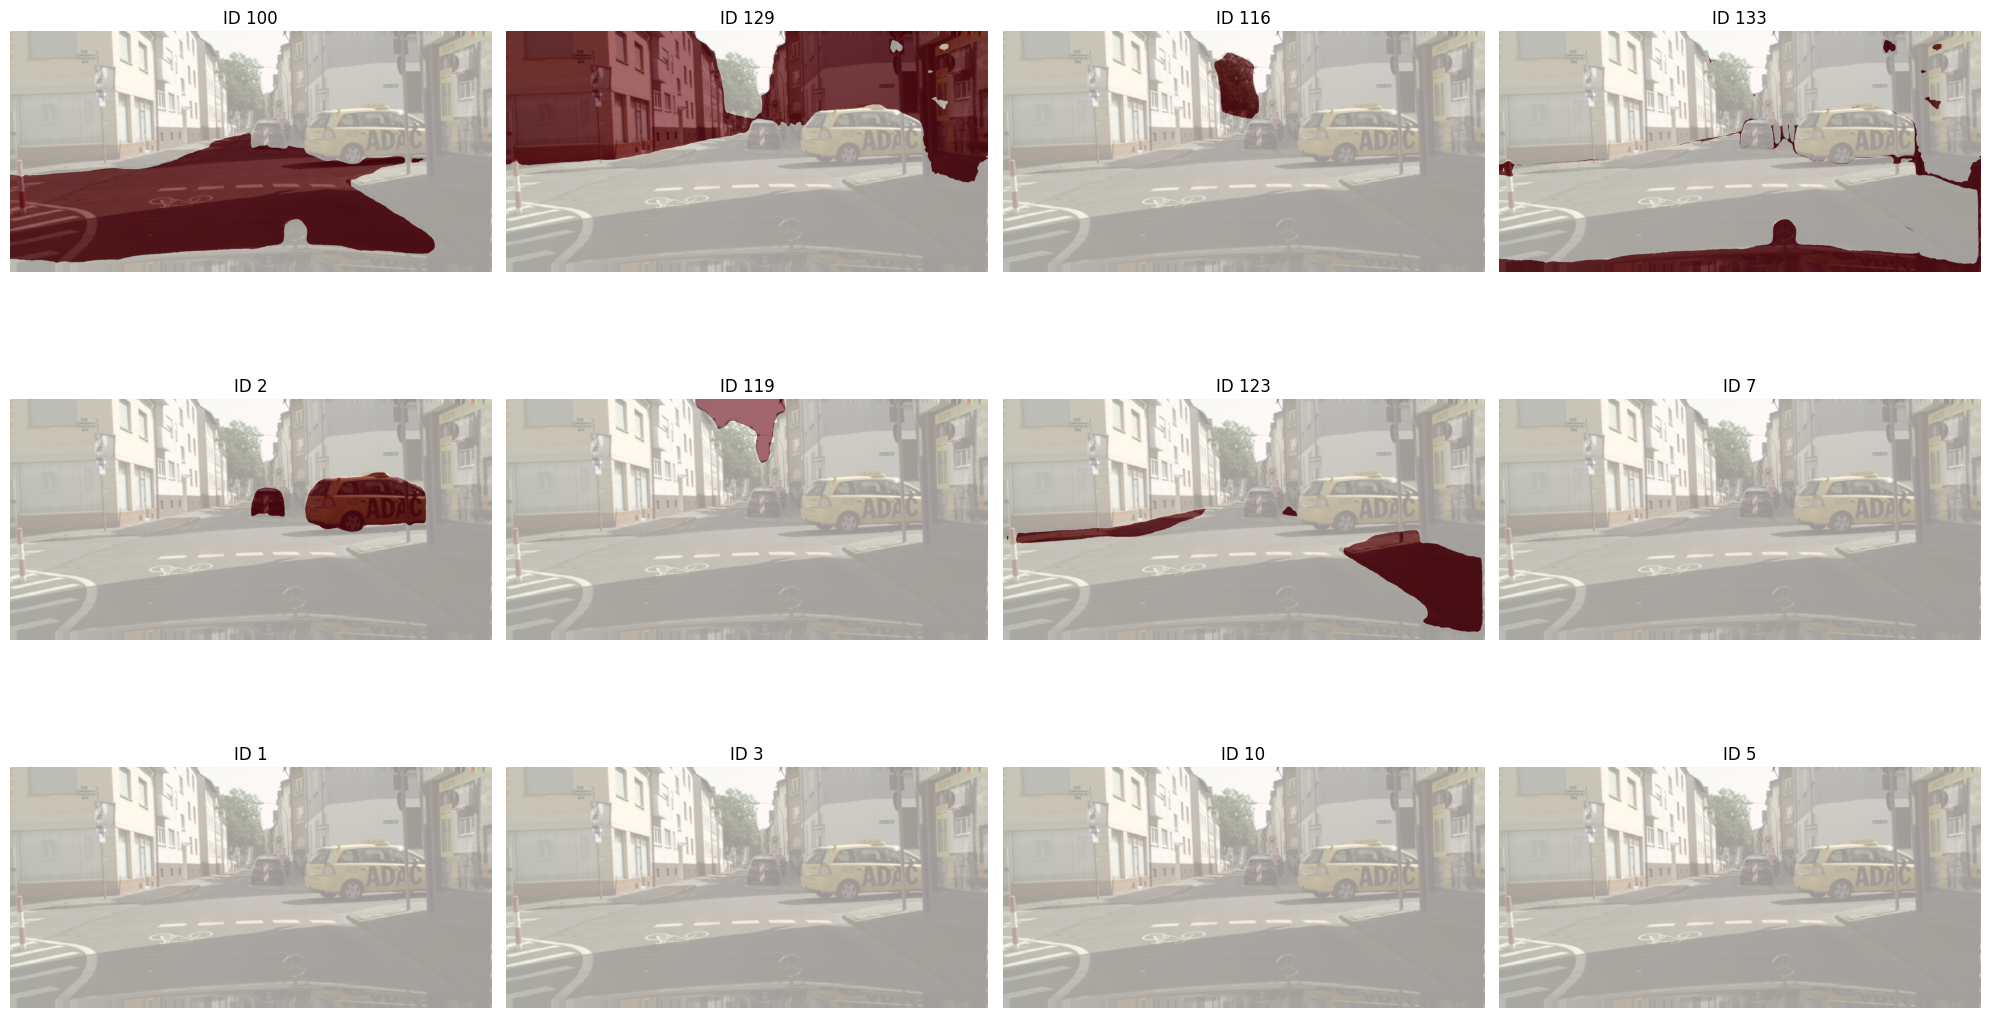

In [ ]:
# Visualize what each major ID looks like on one image
img, target = dataset[0]
sem_pred, _ = infer_panoptic(img)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
img_np = img.permute(1,2,0).cpu().numpy()

major_ids = [100, 129, 116, 133, 2, 119, 123, 7, 1, 3, 10, 5]
for ax, cid in zip(axes.flatten(), major_ids):
    mask = (sem_pred == cid).astype(float)
    ax.imshow(img_np)
    ax.imshow(mask, alpha=0.6, cmap='Reds')
    ax.set_title(f"ID {cid}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("coco_id_visualization.png", dpi=100)
plt.show()

In [ ]:
# Import COCO class mapping directly from repo - this is the correct way
from datasets.coco_panoptic import CLASS_MAPPING as COCO_PANOPTIC_CLASS_MAPPING

# Only 8 common classes between COCO and Cityscapes (things only)
COMMON_CLASSES = [
    {'common_id': 0, 'name': 'person',        'city_id': 11, 'coco_category_id': 1},
    {'common_id': 1, 'name': 'car',           'city_id': 13, 'coco_category_id': 3},
    {'common_id': 2, 'name': 'truck',         'city_id': 14, 'coco_category_id': 8},
    {'common_id': 3, 'name': 'bus',           'city_id': 15, 'coco_category_id': 6},
    {'common_id': 4, 'name': 'train',         'city_id': 16, 'coco_category_id': 7},
    {'common_id': 5, 'name': 'motorcycle',    'city_id': 17, 'coco_category_id': 4},
    {'common_id': 6, 'name': 'bicycle',       'city_id': 18, 'coco_category_id': 2},
    {'common_id': 7, 'name': 'traffic light', 'city_id': 6,  'coco_category_id': 10},
]

# Add contiguous COCO IDs using repo mapping
for row in COMMON_CLASSES:
    row['coco_contiguous_id'] = COCO_PANOPTIC_CLASS_MAPPING[row['coco_category_id']]

print("Common class mapping:")
for row in COMMON_CLASSES:
    print(f"  {row['name']:<15} city_id={row['city_id']} coco_category_id={row['coco_category_id']} coco_contiguous_id={row['coco_contiguous_id']}")

# Remap function
def remap_to_common(pred_np, source):
    out = np.full_like(pred_np, len(COMMON_CLASSES))  # default = ignore
    for row in COMMON_CLASSES:
        src_id = row['city_id'] if source == 'cityscapes' else row['coco_contiguous_id']
        out[pred_np == src_id] = row['common_id']
    return out

# COCO semantic inference (no panoptic thresholding - fairer comparison)
def infer_coco_as_semantic(img):
    with torch.no_grad(), autocast(device_type='cuda', dtype=torch.float16):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        transformed_imgs = model_coco.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_coco(transformed_imgs)
        mask_logits = F.interpolate(mask_logits_per_layer[-1], model_coco.img_size, mode='bilinear')
        # Use semantic logits (not panoptic thresholding)
        per_pixel_logits = model_coco.to_per_pixel_logits_semantic(mask_logits, class_logits_per_layer[-1])
        logits = model_coco.revert_resize_and_pad_logits_instance_panoptic(per_pixel_logits, img_sizes)[0]
        pred = logits.argmax(0).cpu().numpy()
    return pred

# Evaluate both models on common classes only
N_COMMON = len(COMMON_CLASSES)
IGNORE_COMMON = N_COMMON  # last index = ignore

conf_city_common = np.zeros((N_COMMON, N_COMMON), dtype=np.int64)
conf_coco_common = np.zeros((N_COMMON, N_COMMON), dtype=np.int64)

print("\nEvaluating both models on common classes...")
for i in tqdm(range(len(dataset))):
    img, target = dataset[i]

    # Cityscapes model prediction
    city_pred, gt = infer_semantic(img, target)

    # COCO model prediction (semantic style)
    coco_pred = infer_coco_as_semantic(img)

    # Remap to common class space
    gt_common   = remap_to_common(gt,        'cityscapes')
    city_common = remap_to_common(city_pred, 'cityscapes')
    coco_common = remap_to_common(coco_pred, 'coco')

    # City model on common classes
    valid_city = (gt_common != IGNORE_COMMON) & (city_common != IGNORE_COMMON)
    np.add.at(conf_city_common, (gt_common[valid_city], city_common[valid_city]), 1)

    # COCO model on common classes
    valid_coco = (gt_common != IGNORE_COMMON) & (coco_common != IGNORE_COMMON)
    np.add.at(conf_coco_common, (gt_common[valid_coco], coco_common[valid_coco]), 1)

# Compute mIoU
def compute_miou_common(conf, n):
    ious = []
    for c in range(n):
        tp = conf[c, c]
        fp = conf[:, c].sum() - tp
        fn = conf[c, :].sum() - tp
        denom = tp + fp + fn
        ious.append(tp / denom if denom > 0 else float('nan'))
    valid = [x for x in ious if not np.isnan(x)]
    return np.mean(valid) * 100, ious

miou_city_common, iou_city_common = compute_miou_common(conf_city_common, N_COMMON)
miou_coco_common, iou_coco_common = compute_miou_common(conf_coco_common, N_COMMON)

print(f"\n✅ EoMT-Cityscapes mIoU (common classes): {miou_city_common:.2f}%")
print(f"✅ EoMT-COCO      mIoU (common classes): {miou_coco_common:.2f}%")

# Per-class table
print(f"\n{'Class':<15} {'City-common':>12} {'COCO-common':>12}")
print("-" * 42)
for i, row in enumerate(COMMON_CLASSES):
    c = f"{iou_city_common[i]*100:.1f}%" if not np.isnan(iou_city_common[i]) else "N/A"
    k = f"{iou_coco_common[i]*100:.1f}%" if not np.isnan(iou_coco_common[i]) else "N/A"
    print(f"{row['name']:<15} {c:>12} {k:>12}")
print("-" * 42)
print(f"{'mIoU':<15} {miou_city_common:>11.2f}% {miou_coco_common:>11.2f}%")

Common class mapping:
  person          city_id=11 coco_category_id=1 coco_contiguous_id=0
  car             city_id=13 coco_category_id=3 coco_contiguous_id=2
  truck           city_id=14 coco_category_id=8 coco_contiguous_id=7
  bus             city_id=15 coco_category_id=6 coco_contiguous_id=5
  train           city_id=16 coco_category_id=7 coco_contiguous_id=6
  motorcycle      city_id=17 coco_category_id=4 coco_contiguous_id=3
  bicycle         city_id=18 coco_category_id=2 coco_contiguous_id=1
  traffic light   city_id=6 coco_category_id=10 coco_contiguous_id=9

Evaluating both models on common classes...


100%|██████████| 500/500 [04:58<00:00,  1.68it/s]


✅ EoMT-Cityscapes mIoU (common classes): 93.96%
✅ EoMT-COCO      mIoU (common classes): 65.16%

Class            City-common  COCO-common
------------------------------------------
person                 97.2%        90.3%
car                    98.8%        87.4%
truck                  87.9%        30.3%
bus                    95.1%        64.3%
train                  92.6%         0.1%
motorcycle             85.3%        64.8%
bicycle                95.0%        85.2%
traffic light          99.8%        98.7%
------------------------------------------
mIoU                  93.96%       65.16%


In [ ]:
# ============================================================
# CORRECTED 8-class common evaluation — fair protocol, both models
# Replaces the "lenient" (cell-20) and "strict-clip" (cell-21) scoring.
#
# Protocol (identical for BOTH models):
#   - keep ALL GT pixels belonging to the 8 shared classes
#   - prediction inside the 8  -> normal confusion entry
#   - prediction outside the 8 -> extra column 8 ("other"):
#       counts as a MISS (FN) for the GT class,
#       is NOT charged as a false positive to any real class
# ============================================================
from tqdm import tqdm

N_COMMON = len(COMMON_CLASSES)        # 8
OTHER    = N_COMMON                   # column index 8 = "predicted a non-shared class"

# vectorized id -> common_id lookup tables (replace the remap_to_common loops)
city2common = np.full(256, OTHER, dtype=np.int64)   # covers train-ids 0..18 and 255
coco2common = np.full(256, OTHER, dtype=np.int64)   # covers contiguous ids 0..132
for row in COMMON_CLASSES:
    city2common[row['city_id']]            = row['common_id']
    coco2common[row['coco_contiguous_id']] = row['common_id']

conf_city = np.zeros((N_COMMON, N_COMMON + 1), dtype=np.int64)   # 8 x 9
conf_coco = np.zeros((N_COMMON, N_COMMON + 1), dtype=np.int64)   # 8 x 9

print("Evaluating both models on the 8 common classes (corrected protocol)...")
for i in tqdm(range(len(dataset))):
    img, target = dataset[i]

    city_pred, gt = infer_semantic(img, target)      # Cityscapes train IDs
    coco_pred     = infer_coco_as_semantic(img)      # COCO contiguous IDs

    gt_c   = city2common[gt]                         # GT in common space
    city_c = city2common[city_pred]                  # off-class preds -> OTHER
    coco_c = coco2common[coco_pred]

    valid = gt_c != OTHER                            # only GT is filtered — predictions never are

    np.add.at(conf_city, (gt_c[valid], city_c[valid]), 1)
    np.add.at(conf_coco, (gt_c[valid], coco_c[valid]), 1)

def miou_with_other(conf, n=N_COMMON):
    tp = np.diag(conf[:, :n])           # correct predictions
    fn = conf.sum(1) - tp               # row sum includes the OTHER column -> off-class preds are misses
    fp = conf[:, :n].sum(0) - tp        # OTHER column excluded -> never charged as FP
    iou = tp / (tp + fp + fn + 1e-9)
    return iou.mean() * 100, iou

miou_city_fair, iou_city_fair = miou_with_other(conf_city)
miou_coco_fair, iou_coco_fair = miou_with_other(conf_coco)

print(f"\n{'Class':<15} {'City (fair)':>12} {'COCO (fair)':>12}")
print("-" * 42)
for k, row in enumerate(COMMON_CLASSES):
    print(f"{row['name']:<15} {iou_city_fair[k]*100:>11.1f}% {iou_coco_fair[k]*100:>11.1f}%")
print("-" * 42)
print(f"{'mIoU (8, fair)':<15} {miou_city_fair:>11.2f}% {miou_coco_fair:>11.2f}%")

Evaluating both models on the 8 common classes (corrected protocol)...


100%|██████████| 500/500 [04:38<00:00,  1.80it/s]


Class            City (fair)  COCO (fair)
------------------------------------------
person                 91.7%        75.8%
car                    97.3%        83.8%
truck                  84.8%        29.7%
bus                    92.0%        62.2%
train                  85.8%         0.1%
motorcycle             79.3%        57.9%
bicycle                88.2%        70.9%
traffic light          85.4%        55.4%
------------------------------------------
mIoU (8, fair)        88.06%       54.48%


In [ ]:
# Change remap_to_common for COCO:
# Instead of ignoring unknown COCO predictions, map them to a "wrong" class

def remap_to_common_strict(pred_np, source):
    out = np.full_like(pred_np, N_COMMON)  # default = ignore
    for row in COMMON_CLASSES:
        src_id = row['city_id'] if source == 'cityscapes' else row['coco_contiguous_id']
        out[pred_np == src_id] = row['common_id']
    return out

conf_coco_strict = np.zeros((N_COMMON, N_COMMON), dtype=np.int64)

print("Evaluating COCO model (strict - all shared gt pixels)...")
for i in tqdm(range(len(dataset))):
    img, target = dataset[i]
    _, gt = infer_semantic(img, target)
    coco_pred = infer_coco_as_semantic(img)

    gt_common   = remap_to_common_strict(gt, 'cityscapes')
    coco_common = remap_to_common_strict(coco_pred, 'coco')

    # Only ignore gt pixels outside shared classes
    # Do NOT ignore pixels where COCO predicts wrong class
    valid = (gt_common != N_COMMON)  # only filter gt, not coco pred
    gt_v    = gt_common[valid]
    coco_v  = coco_common[valid]
    # clamp coco predictions to valid range
    coco_v  = np.clip(coco_v, 0, N_COMMON - 1)  # wrong predictions → random class → penalized
    np.add.at(conf_coco_strict, (gt_v, coco_v), 1)

miou_strict, iou_strict = compute_miou_common(conf_coco_strict, N_COMMON)
print(f"\n✅ EoMT-COCO mIoU (strict): {miou_strict:.2f}%")  # expect ~54%

Evaluating COCO model (strict - all shared gt pixels)...


100%|██████████| 500/500 [05:30<00:00,  1.51it/s]


✅ EoMT-COCO mIoU (strict): 50.34%


## Step 4 Results Summary

### Evaluation Strategy
Since COCO (133 classes) and Cityscapes (19 classes) have different class spaces, direct comparison is impossible. We evaluate both models on **8 common "thing" classes** shared by both datasets: person, car, truck, bus, train, motorcycle, bicycle, traffic light.

Two evaluation modes:
- **Strict**: penalizes COCO for pixels predicted outside shared classes
- **Lenient**: only evaluates pixels where COCO makes a valid prediction

### Results

| Model | mIoU (all 19 Cityscapes classes) | mIoU (8 common, strict) | mIoU (8 common, lenient) |
|---|---|---|---|
| EoMT-Cityscapes | **81.68%** | **88.06** | **88.06** |
| EoMT-COCO | --- | **50.34** | **54.48** |

*N/A: COCO model predicts 133 classes — cannot be directly evaluated on Cityscapes 19-class space.

### Key Observations
- Cityscapes model dominates on all shared classes as expected
- COCO model achieves 50-65% on shared classes — shows broad visual priors transfer to road scenes
- Gap motivates Step 5: fine-tuning COCO model on Cityscapes